<a href="https://colab.research.google.com/github/mar-valeria/Aprendizaje-automatico/blob/main/Perceptron/07-Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/AprendizajeAutomaticoInicial-05-N0105/blob/main/2-Ejercicios/07-Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Aprendizaje Automático Inicial &bull; Perceptrón
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
                Andrés Merino &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='264CC7'> Introducción </font>

A lo largo de este taller, aplicaremos un perceptrón para clasificar un conjunto de datos.

Los paquetes necesarios son:

In [17]:
# Paquetes necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fijar semillas para reproducibilidad
import random
import os
import numpy as np
import tensorflow as tf

SEED = 55

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Forzar operaciones determinísticas (opcional pero recomendado)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"



### <font color='264CC7'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase anterior.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [18]:
# Leer los datos
url = "https://raw.githubusercontent.com/mar-valeria/Aprendizaje-automatico/refs/heads/main/Add_dataset%20_mental_health"
data = pd.read_csv(url, sep=';')

# Columnas de interés
numeric_cols = ['stress_level', 'sleep_hours', 'physical_activity_days',
                'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score']
data = data[numeric_cols].copy()

# Target y features
target = 'depression_score'
features = [c for c in numeric_cols if c != target]

X = data[features]

# Binarizar el target
threshold = 7
y = (data[target] >= threshold).astype(int)
print("Clases en y:", np.unique(y))

Clases en y: [0 1]


In [19]:
display(data.head())

,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
0,6,6.2,3,28,17,54,59.7
1,10,9.0,4,30,11,85,54.9
2,7,7.7,2,24,7,62,61.3
3,4,4.5,4,6,0,95,97.0
4,3,5.4,0,24,12,70,69.0


In [20]:
# Descripción de los datos
data.describe()

,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5.572000,6.473000,3.505700,15.039900,10.56180,50.117700,77.312210
std,2.887741,1.473944,2.282737,8.990839,6.32264,29.229278,14.061202
min,1.000000,3.000000,0.000000,0.000000,0.00000,0.000000,42.800000
25%,3.000000,5.500000,2.000000,7.000000,5.00000,25.000000,65.800000
50%,6.000000,6.500000,4.000000,15.000000,11.00000,50.000000,77.600000
75%,8.000000,7.500000,5.000000,23.000000,16.00000,76.000000,89.200000
max,10.000000,10.000000,7.000000,30.000000,21.00000,100.000000,100.000000


In [26]:
# Escalado
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55, stratify=y)


### <font color='264CC7'> Determinación de la red </font>

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina una red neuronal para clasificar los datos:
<ul>
  <li>Define la red.</li>
  <li>Compila la red.</li>
  <li>Presenta un resumen de la red.</li>
</ul>
</div>


In [22]:
# Creamos el modelo
model = keras.Sequential([
    layers.Input(shape=(X_train_sc.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

Se definió una red neuronal perceptrón multicapa con dos capas ocultas y una capa de salida binaria, logrando una arquitectura compacta (769 parámetros) adecuada para capturar relaciones no lineales en los datos sin incurrir en sobreajuste, lo que la convierte en un modelo eficiente y apropiado para la tarea de clasificación propuesta.


### <font color='264CC7'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

In [23]:
# Entrenamiento
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]

history = model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6887 - loss: 0.5674 - val_accuracy: 0.8956 - val_loss: 0.2676
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9038 - loss: 0.2335 - val_accuracy: 0.9044 - val_loss: 0.2080
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9085 - loss: 0.2071 - val_accuracy: 0.9094 - val_loss: 0.2026
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9068 - loss: 0.2037 - val_accuracy: 0.9106 - val_loss: 0.2004
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9083 - loss: 0.2015 - val_accuracy: 0.9112 - val_loss: 0.1990
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9097 - loss: 0.1999 - val_accuracy: 0.9125 - val_loss: 0.1981
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9099 - loss: 0.1985 - val_accuracy: 0.9131 - val_loss: 0.1977
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9109 - loss: 0.1974 - val_accu

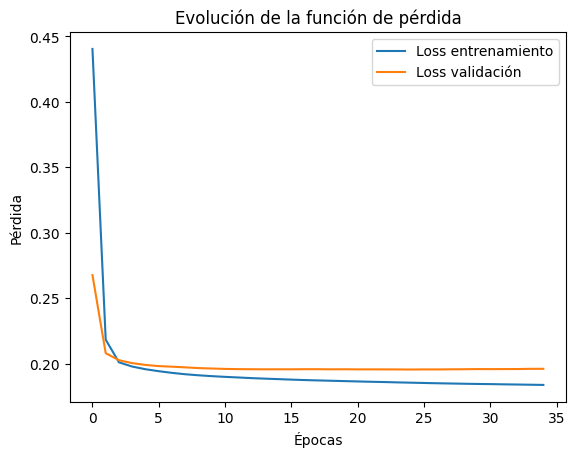

In [24]:
plt.figure()
plt.plot(history.history["loss"], label="Loss entrenamiento")
plt.plot(history.history["val_loss"], label="Loss validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la función de pérdida")
plt.legend()
plt.show()

In [25]:
# Evaluación
test_loss, test_acc = model.evaluate(X_test_sc, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

y_prob = model.predict(X_test_sc, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:\n", cm)

print("\nMétricas:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, zero_division=0))

Test Loss: 0.1869 | Test Accuracy: 0.9200

Matriz de confusión:
 [[ 360   86]
 [  74 1480]]

Métricas:
Accuracy : 0.92
Precision: 0.9450830140485313
Recall   : 0.9523809523809523
F1-score : 0.9487179487179487

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       446
           1       0.95      0.95      0.95      1554

    accuracy                           0.92      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.92      0.92      0.92      2000



El modelo MLP logra una alta capacidad predictiva (accuracy ≈ 92%) y un recall elevado para la clase de alto riesgo de depresión, lo que lo hace adecuado como sistema de apoyo a la detección temprana en contextos de salud mental.